# Skan TEST


In [ ]:
From https://jni.github.io/skan/index.html

In [39]:
from glob import glob

import imageio as iio


In [40]:
import matplotlib.pyplot as plt

In [41]:
files = glob('/Volumes/groups/zimmer/Ulises/code/unet-master/data/crop_worm_raw_eroded_twice/training_results_100epochs/24194609_w_validation500steps_100epochs/test_predictions/*.png')

image0 = iio.imread(files[0])

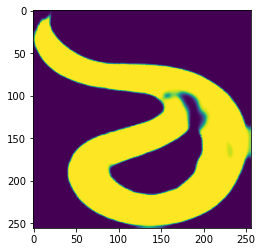

In [42]:
plt.imshow(image0)

In [43]:
spacing_nm=1

/Users/ulises.rey/opt/anaconda3/envs/skan/lib/python3.9/site-packages/skan/vendored/thresholding.py:122: RuntimeWarning: invalid value encountered in sqrt
  s = np.sqrt(g2 - m * m)


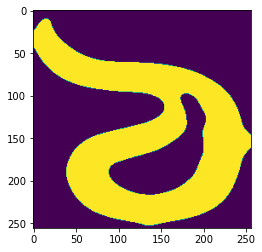

In [44]:
from skan.pre import threshold

smooth_radius = 5 / spacing_nm  # float OK


threshold_radius = int(np.ceil(50 / spacing_nm))

binary0 = threshold(image0, sigma=smooth_radius,

                    radius=threshold_radius)


fig, ax = plt.subplots()

ax.imshow(binary0);

In [48]:
from skimage import morphology

skeleton0 = morphology.skeletonize(binary0)


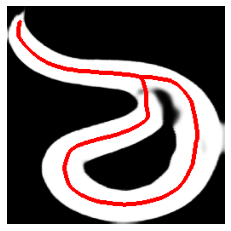

In [49]:
from skan import draw
fig, ax = plt.subplots()

draw.overlay_skeleton_2d(image0, skeleton0, dilate=2, axes=ax);

In [50]:
from skan import skeleton_to_csgraph


pixel_graph, coordinates, degrees = skeleton_to_csgraph(skeleton0)

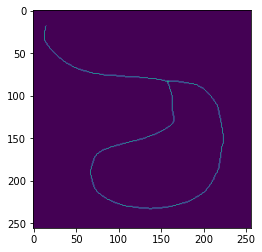

In [52]:
fig,ax=plt.subplots()
ax.imshow(degrees)

<AxesSubplot:>

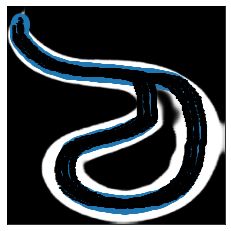

In [53]:
fig,ax=plt.subplots()
draw.overlay_skeleton_networkx(pixel_graph, coordinates, image=image0, axis=ax)


## In a for loop

In [54]:
from glob import glob
import imageio as iio
import matplotlib.pyplot as plt
from skimage import morphology
from skan import draw
from skan.pre import threshold
from skan import skeleton_to_csgraph
import cv2
from skan import Skeleton, summarize


In [55]:
spacing_nm=2

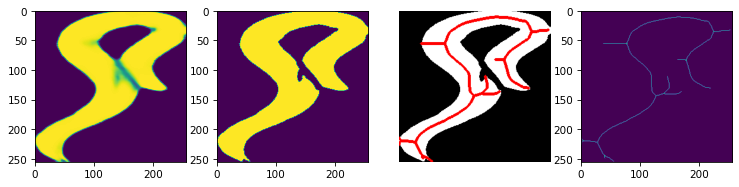

In [56]:
files = glob('/Volumes/groups/zimmer/Ulises/code/unet-master/data/a_new_crop_worm_eroded/training_results/24264142_w_validation500steps_50epochs/test_predictions/*.png')

for file in files:
    #print(file)
    image0 = iio.imread(file)
    smooth_radius = 5 / spacing_nm  # float OK


    threshold_radius = int(np.ceil(50 / spacing_nm))

#     binary0 = threshold(image0, sigma=smooth_radius,

#                         radius=threshold_radius)

    ret,binary0=cv2.threshold(image0,200,1,cv2.THRESH_BINARY)
#     plt.imshow(binary0)
#     plt.show()

    skeleton0 = morphology.skeletonize(binary0)
    fig, ax = plt.subplots(figsize=(12,4),ncols=4,dpi=75)
    ax[0].imshow(image0)
    binary=binary0*255
    ax[1].imshow(binary0)
    draw.overlay_skeleton_2d(binary, skeleton0, dilate=2, axes=ax[2]);
    
    #degrees
    pixel_graph, coordinates, degrees = skeleton_to_csgraph(skeleton0)
    ax[3].imshow(degrees)
    #branch data
    branch_data = summarize(Skeleton(skeleton0, spacing=spacing_nm))

    branch_data.head()
    break

In [57]:


branch_data = summarize(Skeleton(skeleton0, spacing=spacing_nm))

branch_data.head()

,skeleton-id,node-id-src,node-id-dst,branch-distance,branch-type,mean-pixel-value,stdev-pixel-value,image-coord-src-0,image-coord-src-1,image-coord-dst-0,image-coord-dst-1,coord-src-0,coord-src-1,coord-dst-0,coord-dst-1,euclidean-distance
0,1,141,160,57.884628,1,1.0,0.0,33.000000,251.000000,35.666667,223.333333,66.000000,502.000000,71.333333,446.666667,55.589767
1,1,160,165,371.721235,2,1.0,0.0,35.666667,223.333333,56.000000,76.750000,71.333333,446.666667,112.000000,153.500000,295.973769
2,1,160,166,146.797314,2,1.0,0.0,35.666667,223.333333,84.000000,176.750000,71.333333,446.666667,168.000000,353.500000,134.255250
3,1,165,217,79.500000,1,1.0,0.0,56.000000,76.750000,56.000000,37.000000,112.000000,153.500000,112.000000,74.000000,79.500000
4,1,165,256,220.138777,2,1.0,0.0,56.000000,76.750000,144.000000,126.000000,112.000000,153.500000,288.000000,252.000000,201.688497


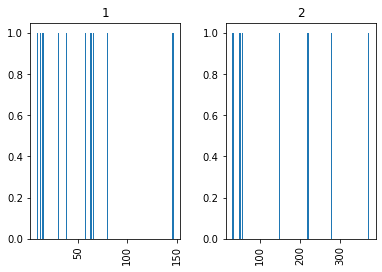

In [58]:
branch_data.hist(column='branch-distance', by='branch-type', bins=100);

In [59]:
branch_data

,skeleton-id,node-id-src,node-id-dst,branch-distance,branch-type,mean-pixel-value,stdev-pixel-value,image-coord-src-0,image-coord-src-1,image-coord-dst-0,image-coord-dst-1,coord-src-0,coord-src-1,coord-dst-0,coord-dst-1,euclidean-distance
0,1,141,160,57.884628,1,1.0,0.0,33.000000,251.000000,35.666667,223.333333,66.000000,502.000000,71.333333,446.666667,55.589767
1,1,160,165,371.721235,2,1.0,0.0,35.666667,223.333333,56.000000,76.750000,71.333333,446.666667,112.000000,153.500000,295.973769
2,1,160,166,146.797314,2,1.0,0.0,35.666667,223.333333,84.000000,176.750000,71.333333,446.666667,168.000000,353.500000,134.255250
3,1,165,217,79.500000,1,1.0,0.0,56.000000,76.750000,56.000000,37.000000,112.000000,153.500000,112.000000,74.000000,79.500000
4,1,165,256,220.138777,2,1.0,0.0,56.000000,76.750000,144.000000,126.000000,112.000000,153.500000,288.000000,252.000000,201.688497
5,1,166,319,30.031129,1,1.0,0.0,84.000000,176.750000,83.000000,162.000000,168.000000,353.500000,166.000000,324.000000,29.567719
6,1,166,469,146.741807,1,1.0,0.0,84.000000,176.750000,131.000000,218.000000,168.000000,353.500000,262.000000,436.000000,125.068981
7,1,215,392,66.553021,1,1.0,0.0,139.666667,139.666667,111.000000,145.000000,279.333333,279.333333,222.000000,290.000000,58.317141
8,1,215,256,30.713055,2,1.0,0.0,139.666667,139.666667,144.000000,126.000000,279.333333,279.333333,288.000000,252.000000,28.674418
9,1,215,483,63.084945,1,1.0,0.0,139.666667,139.666667,137.000000,169.000000,279.333333,279.333333,274.000000,338.000000,58.908592
